In [86]:
# Cement

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, models_output_dict)

In [87]:


# cement
cement = ResourceModel(resource_group = 'nmm', resource = 'cement', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)
# cement net trade
# Historical export per region for Cement (Mtonne), 1970-2000 + 2100 (constant from 2000 on) 
# (because export and import did not add up to 0, import has been increased by 25%, see Roorda, page 13)

high = ['class_ 16', 'class_ 20']

medium = ['class_ 1','class_ 13', 'class_ 23',
          'class_ 2',  'class_ 3', 'class_ 11' , 'class_ 24'] 


# trajectory not to forseen, will be fitted with global regression

# what is in rset will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (high+medium)]

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
cement_grouping = {'all' : all_regions_list_class[:-1],
                  'high': high,
                  'medium': medium,
                  }

#cement_grouping = {'all' : all_regions_list_class[:-1]}
cement.data_grouped_regions(regions_grouping = cement_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
cement.sum_IMAGE_drivers_regions(regions_dict=None)

cement.match_MAT_data_to_regions_year(match_external_regions=False)
cement.calculate_historic_other_fraction()

# deal with single negative numbers by removing them from dataset
cement.historic_other_fraction_consumption[cement.historic_other_fraction_consumption < 0] = np.nan


In [88]:
# Fit models 
cement.calculate_regressors(cement.historic_other_fraction_consumption)

best_rmse_models={
    'all' : 'gompertz model',
    'high': 'gompertz model',
    'medium': 'gompertz model'}

bounds = {
    'all' : ([0, 0, 0], [10, 10, 10]),
    'high': ([0, 0, 0], [10, 10, 10]),
    'medium': ([0, 5, 0], [10, 10, 10]),
}

cement.fit_models(best_rmse_models, bounds)

# Best models
cement.best_rmse_models
cement.merged_rmse_r2

# project based on best model
cement.project_on_total(all_regions_list_class[:-1])

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d


In [89]:
cement.historic_other_fraction_consumption

,class_ 1,class_ 10,class_ 11,class_ 12,class_ 13,class_ 14,class_ 15,class_ 16,class_ 17,class_ 18,...,class_ 24,class_ 25,class_ 26,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9
t,,,,,,,,,,,,,,,,,,,,,
1971,2975897.774,3.944520e+06,1.093063e+08,2.809954e+07,4.081450e+06,NaN,NaN,8.291130e+07,4.741445e+06,NaN,...,1983550.240,NaN,157761.268,NaN,6.065342e+05,2.231709e+06,9.064279e+06,2.638310e+06,NaN,NaN
1972,NaN,4.207827e+06,8.518112e+07,3.042765e+07,2.258653e+06,NaN,NaN,8.972151e+07,3.383126e+06,NaN,...,2448291.363,NaN,1836783.052,NaN,2.237575e+06,NaN,1.128070e+07,2.870273e+06,NaN,NaN
1973,1995220.783,4.286171e+06,6.141901e+07,3.578113e+07,5.879652e+06,NaN,NaN,9.009450e+07,3.837138e+06,NaN,...,NaN,NaN,2632991.095,1.924477e+04,4.489827e+06,NaN,1.261325e+07,4.280192e+06,NaN,NaN
1974,4841395.211,5.659216e+06,9.582462e+07,2.651743e+07,6.214714e+06,NaN,NaN,1.023899e+08,6.760546e+06,NaN,...,NaN,NaN,3460346.857,3.891749e+06,6.039108e+06,2.430943e+06,2.003993e+07,NaN,NaN,NaN
1975,NaN,5.674537e+06,1.075837e+08,4.144346e+07,6.071883e+06,NaN,NaN,1.093041e+08,NaN,NaN,...,2412181.144,NaN,876210.051,2.232517e+06,2.775841e+06,1.201717e+07,1.318311e+07,3.578455e+06,NaN,NaN
1976,NaN,3.784937e+06,7.491827e+07,3.973247e+07,5.252808e+06,1.843259e+07,NaN,1.077443e+08,1.288483e+07,NaN,...,4187640.178,NaN,1150214.883,3.480242e+06,1.730022e+06,NaN,1.513848e+07,2.195919e+06,NaN,NaN
1977,589175.623,3.012650e+06,8.509040e+07,4.155590e+07,1.061837e+07,1.906709e+07,NaN,1.103409e+08,NaN,NaN,...,NaN,NaN,1437769.402,7.722768e+06,NaN,3.585983e+06,8.625946e+06,2.136013e+06,NaN,NaN
1978,104274.801,2.581766e+06,6.759093e+07,4.050266e+07,1.306382e+07,1.841959e+07,NaN,1.119862e+08,4.292246e+06,NaN,...,138785.634,NaN,727499.752,6.396938e+05,3.313097e+06,1.027801e+07,1.261865e+07,6.170464e+06,NaN,NaN
1979,5051575.715,2.343874e+06,5.950205e+07,4.452548e+07,1.144326e+07,1.926898e+07,NaN,1.121167e+08,1.298301e+07,NaN,...,3566580.504,NaN,596671.387,NaN,7.346554e+06,9.531043e+05,1.170362e+07,7.010581e+06,NaN,NaN


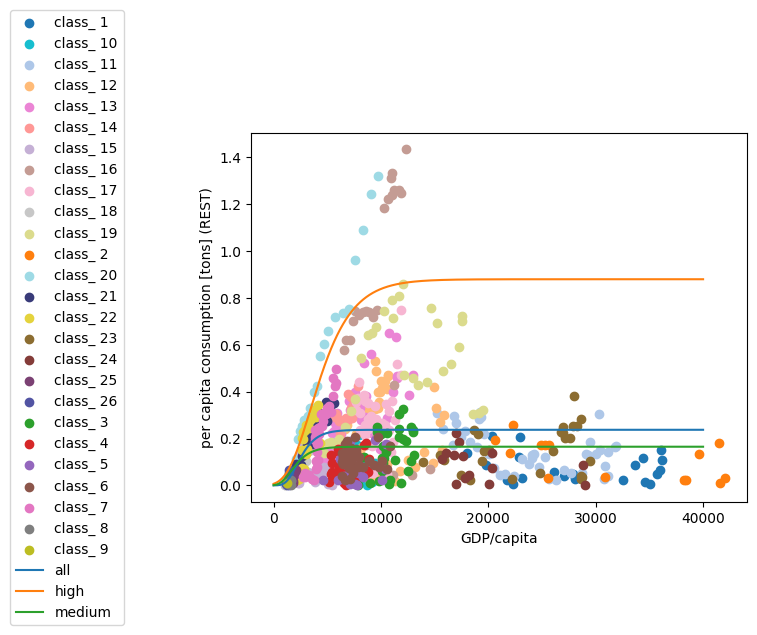

In [90]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in cement.cons_capita.columns:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in cement_grouping.keys():
    model = cement.model_groups[grouping][models_output_dict[cement.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1).astype(float)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


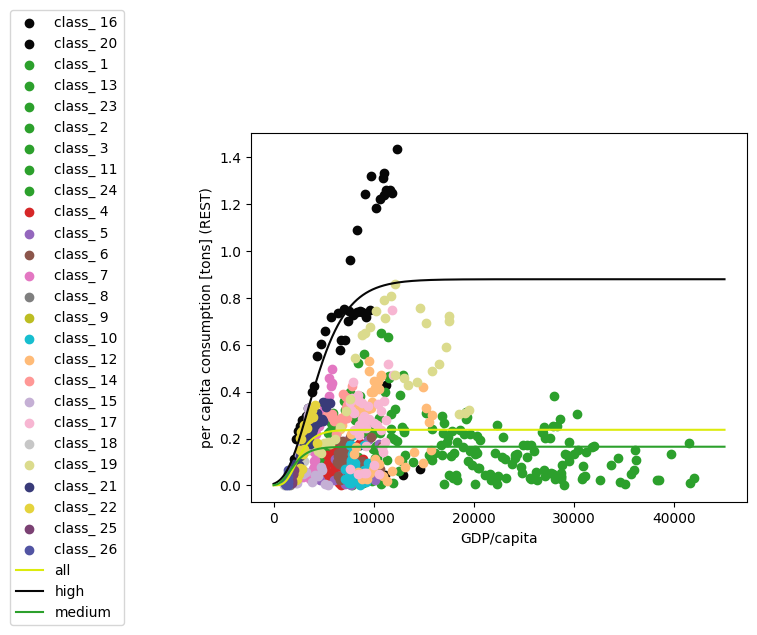

In [91]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'high': color_high,
    'all': "#dceb0c",  # Color for all region
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
    
for region in high:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_high)

for region in medium:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_medium)

for region in rest:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in cement_grouping.keys():
    model = cement.model_groups[grouping][models_output_dict[cement.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))




In [92]:
cement.smooth_out_interpolation_all(10, 2012)

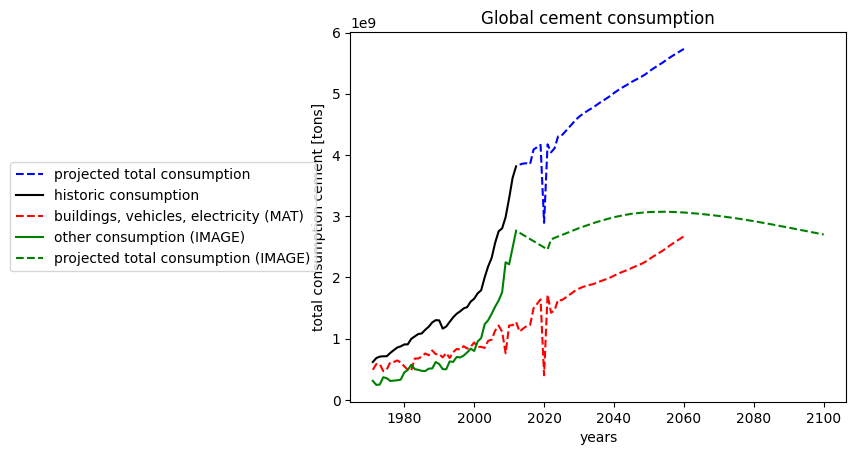

In [99]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(cement.projection_per_region_total.sum(axis = 1).loc[2013:] + cement.image_mat_data.sum(axis = 1).loc[2013:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(cement.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(cement.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(cement.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(cement.projection_per_region_total.loc[2013: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption cement [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global cement consumption")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.7, 0.5))